# 04 - Feature Engineering

I created simple time and past-value features so the models can use recent energy history.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hourly = pd.read_csv(
    "../01_Data/processed/hourly_energy.csv",
    parse_dates=["date_time"]
)

In [3]:
hourly = hourly.sort_values("date_time")

## Calendar features

In [4]:
hourly["hour"] = hourly["date_time"].dt.hour
hourly["dayofweek"] = hourly["date_time"].dt.dayofweek

In [5]:
hourly["month"] = hourly["date_time"].dt.month
hourly["is_weekend"] = (hourly["dayofweek"] >= 5).astype(int)

## Lag features

Lag 1 means previous hour, 24 means previous day, and 168 means same hour one week ago.

In [6]:
hourly["lag_1"] = hourly["energy_kwh"].shift(1)
hourly["lag_24"] = hourly["energy_kwh"].shift(24)

In [7]:
hourly["lag_168"] = hourly["energy_kwh"].shift(168)

## Rolling features

In [8]:
hourly["rolling_24"] = (
    hourly["energy_kwh"].shift(1).rolling(24).mean()
)

In [9]:
hourly["rolling_168"] = (
    hourly["energy_kwh"].shift(1).rolling(168).mean()
)

In [10]:
hourly = hourly.dropna().copy()
print(hourly.shape)

(17234, 15)


## Check the new features

In [11]:
show_cols = ["date_time", "energy_kwh", "lag_1", "lag_24", "lag_168", "rolling_24"]
hourly[show_cols].head()

,date_time,energy_kwh,lag_1,lag_24,lag_168,rolling_24
168,2006-12-23 18:00:00,3.879400,5.452533,2.686967,3.632200,3.099713
169,2006-12-23 19:00:00,4.117833,3.879400,3.938167,3.400233,3.149397
170,2006-12-23 20:00:00,4.181400,4.117833,3.536067,3.268567,3.156883
171,2006-12-23 21:00:00,3.288433,4.181400,4.548667,3.056467,3.183772
172,2006-12-23 22:00:00,4.327933,3.288433,3.065067,2.200133,3.131263


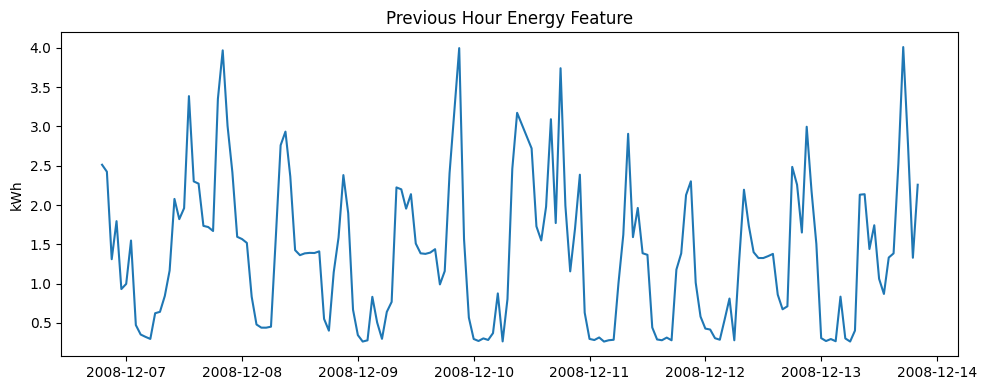

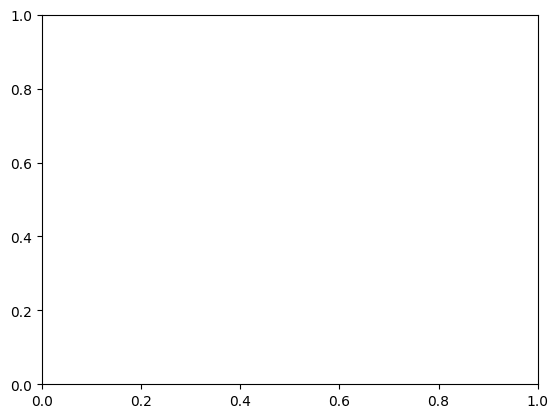

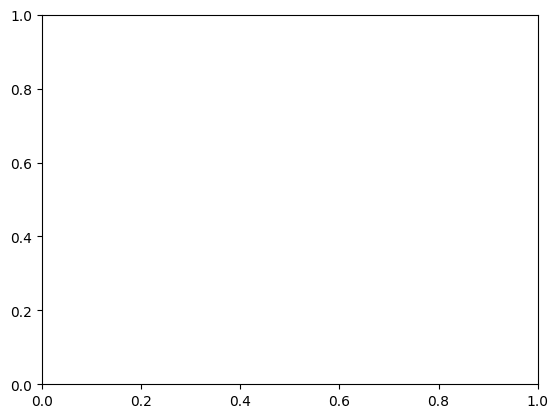

In [12]:
plt.figure(figsize=(10,4))
plt.plot(hourly["date_time"].tail(168), hourly["lag_1"].tail(168))
plt.title("Previous Hour Energy Feature")
plt.ylabel("kWh")
plt.tight_layout()
plt.show()
plt.savefig("../04_Visuals/ml/07_feature_engineering_check.png", dpi=150)
plt.show()
plt.savefig("../04_Visuals/ml/07_feature_engineering_check.png", dpi=150)
plt.show()


## Final feature list

In [13]:
features = [
    "hour", "dayofweek", "month", "is_weekend",
    "lag_1", "lag_24", "lag_168",
    "rolling_24", "rolling_168"
]
print(features)

['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_24', 'rolling_168']


In [14]:
model_data = hourly[["date_time", "energy_kwh"] + features]
model_data.to_csv("../01_Data/processed/model_ready_hourly.csv", index=False)
print("Model-ready rows:", len(model_data))


Model-ready rows: 17234


These features are kept simple on purpose. They are easy to explain in an interview and useful for time-based prediction.